# TS5: Estimación espectral — Ancho de banda de señales reales

En el repositorio **PDStestbench** se encuentran tres tipos de señales registradas:

- **Electrocardiograma (ECG):** en el archivo `ECG_TP4.mat` se incluye un registro electrocardiográfico tomado durante una prueba de esfuerzo, junto con una serie de variables descriptas más abajo.  
- **Pletismografía (PPG):** el archivo `PPG.csv` contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro para esta actividad.  
- **Audio:** tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.

Los detalles sobre cómo acceder a dichos registros se encuentran en el script `lectura_sigs.py`.

---

## Objetivos

1. **Estimación de la densidad espectral de potencia (PSD):**  
   Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

2. **Estimación del ancho de banda:**  
  Realice una estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.

## Introducción

El objetivo de esta tarea es estimar la **densidad espectral de potencia (PSD)** de tres señales reales —ECG, PPG y audio— y, a partir de ella, determinar el **ancho de banda** de cada una.

A diferencia de las tareas anteriores, donde la señal era sintética y se conocía su frecuencia exacta, aquí se trabaja con **señales reales**: no poseen una única frecuencia dominante, sino un **contenido espectral distribuido**, y el interés está en identificar en qué rango de frecuencias se concentra la mayor parte de su potencia.

Se utilizan dos estimadores vistos en clase:

- **Método de Welch**: promediado de periodogramas sobre segmentos solapados.  
- **Método de Blackman–Tukey**: transformada de Fourier de la autocorrelación ventaneada.

Ambos métodos buscan reducir la **varianza del periodograma simple**, que es un estimador inconsistente.


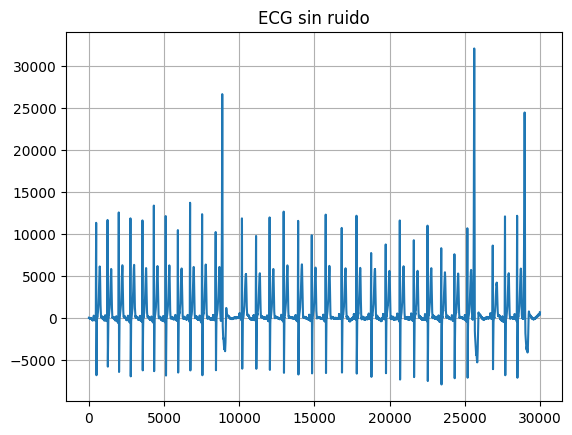

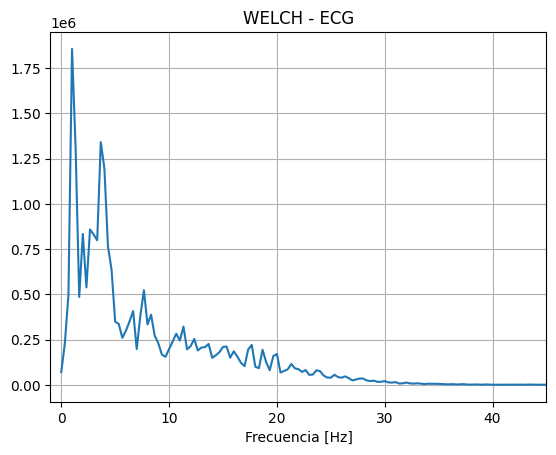

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal as sig

import scipy.io as sio

#%% ECG SIN RUIDO
# Pasa bajos

ecg_one_lead = np.load('ecg_sin_ruido.npy')
fs_ecg = 1000 # Hz
N_ECG = len(ecg_one_lead)
nn_ECG = np.arange(N_ECG)

plt.figure()
plt.plot(nn_ECG, ecg_one_lead)
plt.title("ECG sin ruido")
plt.grid()
plt.show()

# WELCH
cant_promedios_ecg = 10
nperseg = N_ECG // cant_promedios_ecg

f_ecg, Pxx_ecg = sig.welch(ecg_one_lead, fs = fs_ecg, window ='hamming', nperseg = nperseg, noverlap = 10)

plt.figure()
plt.title("WELCH - ECG")
plt.plot(f_ecg, Pxx_ecg)
plt.xlabel('Frecuencia [Hz]')
plt.xlim(-1, 45)
plt.grid()
plt.show()
# Calculo el ancho de banda 
# Para pasa-banda: dos cortes
df_ecg = f_ecg[1] - f_ecg[0]
acum = np.cumsum(Pxx_ecg) * df_ecg
acum_norm = acum / acum[-1]

idx_inf_ecg = np.where(acum_norm >= 0.005)[0][0] # Límite inferior (0.5%)
idx_sup_ecg = np.where(acum_norm >= 0.995)[0][0] # Límite superior (99.5%)

f_inf_ecg = f_ecg[idx_inf_ecg]
f_sup_ecg = f_ecg[idx_sup_ecg]
BW_ecg = f_sup_ecg - f_inf_ecg

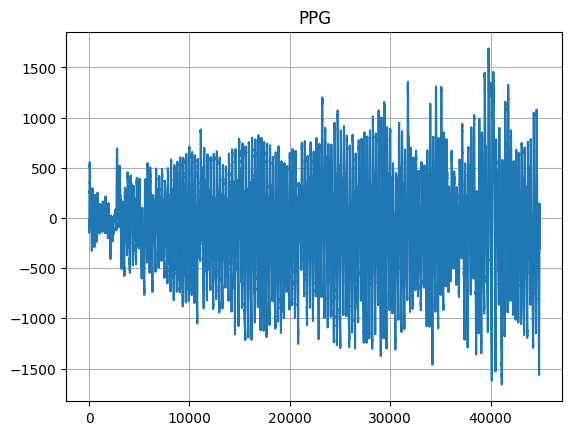

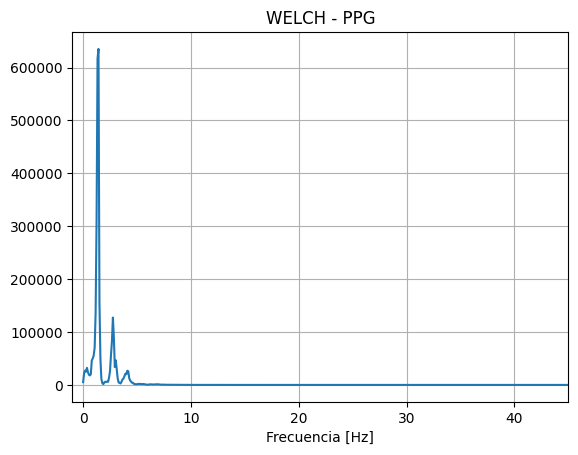

In [2]:
#%% PPG SIN RUIDO
# Pasa bajos 

ppg = np.load('ppg_sin_ruido.npy')
fs_ppg = 400 # Hz
N_PPG = len(ppg)

plt.figure()
plt.title("PPG")
plt.plot(ppg)
plt.grid()
plt.show()

cant_promedios_ppg = 10
nperseg_ppg = N_PPG // cant_promedios_ppg

f_ppg, Pxx_ppg = sig.welch(ppg, fs = fs_ppg, window ='hamming', nperseg = nperseg_ppg)

plt.figure()
plt.title("WELCH - PPG")
plt.plot(f_ppg, Pxx_ppg)
plt.xlim(-1, 45)
plt.xlabel('Frecuencia [Hz]')
plt.grid()
plt.show()

# Calculo el ancho de banda 
# Para pasa-banda: dos cortes
df_ppg = f_ppg[1] - f_ppg[0]
acum = np.cumsum(Pxx_ppg) * df_ppg
acum_norm = acum / acum[-1]

idx_inf_ppg = np.where(acum_norm >= 0.005)[0][0] # Límite inferior (0.5%)
idx_sup_ppg = np.where(acum_norm >= 0.995)[0][0] # Límite superior (99.5%)

f_inf_ppg = f_ppg[idx_inf_ppg]
f_sup_ppg = f_ppg[idx_sup_ppg]
BW_ppg = f_sup_ppg - f_inf_ppg

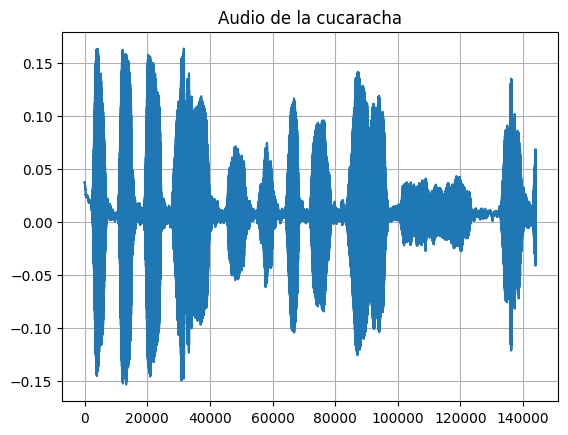

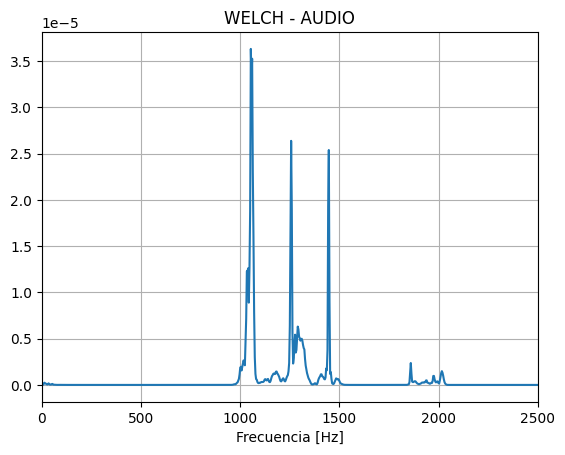

In [3]:
#%% AUDIO 
# Pasa banda

# LA CUCARACHA
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
N_audio = len(wav_data)

plt.figure()
plt.title("Audio de la cucaracha")
plt.plot(wav_data)
plt.grid()
plt.show()

cant_promedio_audio = 10 
nperseg_audio = N_audio // cant_promedio_audio

f_audio, Pxx_audio = sig.welch(wav_data, fs = fs_audio, window ='hamming', nperseg = nperseg_audio)

plt.figure()
plt.title("WELCH - AUDIO")
plt.plot(f_audio, Pxx_audio)
plt.xlim(-1, 2500)
plt.xlabel('Frecuencia [Hz]')
plt.grid()
plt.show()

# Calculo el ancho de banda 
# Pasa-banda -> DOS cortes
df_audio = f_audio[1] - f_audio[0]
acum = np.cumsum(Pxx_audio) * df_audio
acum_norm = acum / acum[-1]

idx_inf_audio = np.where(acum_norm >= 0.005)[0][0]   # limite inferior (0.5%)
idx_sup_audio = np.where(acum_norm >= 0.995)[0][0]   # limite superior (99.5%)

f_inf_audio = f_audio[idx_inf_audio]
f_sup_audio = f_audio[idx_sup_audio]
BW_audio = f_sup_audio - f_inf_audio

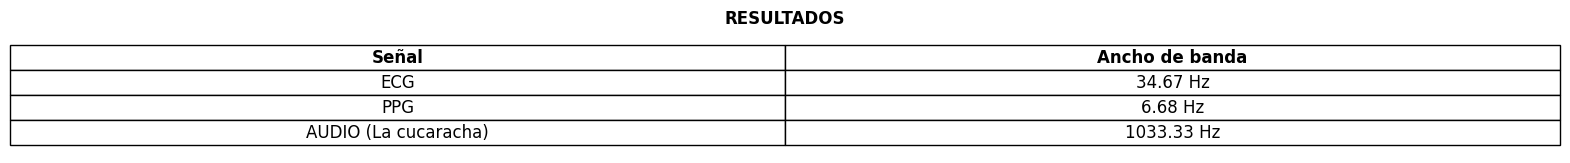

In [4]:
# %% Tabla con los resultados del ancho de banda
data = [
    ["ECG", f"{BW_ecg:.2f} Hz"],
    ["PPG", f"{BW_ppg:.2f} Hz"],
    ["AUDIO (La cucaracha)", f"{BW_audio:.2f} Hz"],
]

fig, ax = plt.subplots(figsize = (20, 1.5))
ax.axis('off')

tabla = ax.table(cellText = data, colLabels = ["Señal", "Ancho de banda"], cellLoc = 'center', loc = 'center')

# Esto es para poner en negrita los "titulos"
tabla[0,0].get_text().set_fontweight('bold')
tabla[0,1].get_text().set_fontweight('bold')

tabla.scale(1, 1.5)
tabla.auto_set_font_size(False)
tabla.set_fontsize(12)

plt.title("RESULTADOS", fontweight = 'bold', pad=10)
plt.show()

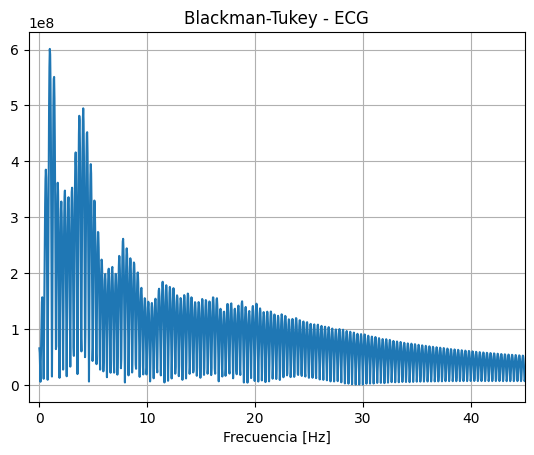

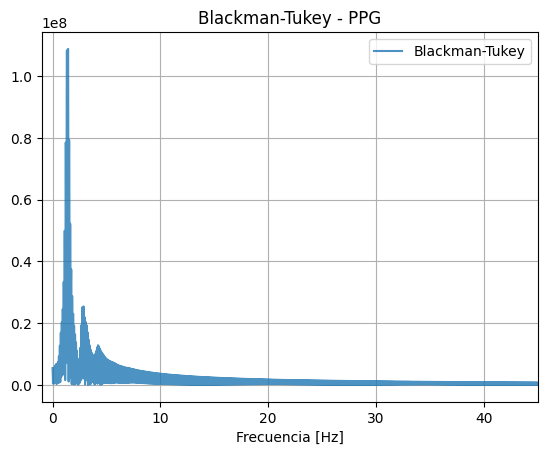

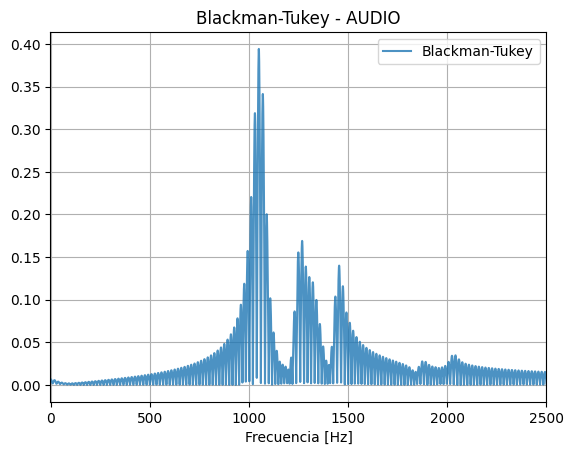

In [5]:
#%% Hago el mismo analisis pero con Blackman - Tukey

def blackman_tukey(x, fs, M=None):
    N = len(x)
    if M is None:
        M = N // 20
    M = min(M, N // 2 - 1)
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)                       # quito la continua

    r_full = np.correlate(x, x, mode='full') / N
    mid = len(r_full) // 2
    r = r_full[mid - (M - 1): mid + M]       # autocorrelacion simetrica, largo 2M-1

    window = sig.windows.blackman(len(r))
    r_windowed = r * window

    # CLAVE: reordeno para que el lag 0 quede en el indice 0 (fftshift),
    # asi la FFT no introduce fase espuria.
    Px = np.abs(np.fft.fft(np.fft.ifftshift(r_windowed), n=N))

    f = np.fft.fftfreq(N, d=1/fs)[:N // 2]
    Px = Px[:N // 2]
    return f, Px

# ECG
f_ecg_bt, Px_ecg_bt = blackman_tukey(ecg_one_lead, fs_ecg, M = N_ECG // 20)
 
plt.figure()
plt.title("Blackman-Tukey - ECG")
plt.plot(f_ecg_bt, Px_ecg_bt)
plt.xlim(-1, 45)
plt.xlabel('Frecuencia [Hz]')
plt.grid()
plt.show()

# PPG
f_ppg_bt, Px_ppg_bt = blackman_tukey(ppg, fs_ppg, M=N_PPG // 20)

plt.figure()
plt.title("Blackman-Tukey - PPG")
plt.plot(f_ppg_bt, Px_ppg_bt, label='Blackman-Tukey', alpha=0.8)
plt.xlim(-1, 45) 
plt.xlabel('Frecuencia [Hz]')
plt.legend() 
plt.grid()
plt.show()

# AUDIO 
f_audio_bt, Px_audio_bt = blackman_tukey(wav_data, fs_audio, M=N_audio // 100)

plt.figure()
plt.title("Blackman-Tukey - AUDIO")
plt.plot(f_audio_bt, Px_audio_bt, label='Blackman-Tukey', alpha=0.8)
plt.xlim(-1, 2500)
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.grid()
plt.show()

In [7]:
#%% Ancho de banda con Blackman-Tukey

# ECG (pasa-bajos -> un corte)
df = f_ecg_bt[1] - f_ecg_bt[0]
acum = np.cumsum(Px_ecg_bt) * df
acum_norm = acum / acum[-1]
idx = np.where(acum_norm >= 0.99)[0][0]
BW_ecg_bt = f_ecg_bt[idx]
# print(f"Ancho de banda del ECG (Blackman-Tukey): Bandwidth = {BW_ecg_bt:.1f} Hz")

# PPG (pasa-bajos -> un corte)
df = f_ppg_bt[1] - f_ppg_bt[0]
acum = np.cumsum(Px_ppg_bt) * df
acum_norm = acum / acum[-1]
idx = np.where(acum_norm >= 0.99)[0][0]
BW_ppg_bt = f_ppg_bt[idx]
# print(f"Ancho de banda del PPG (Blackman-Tukey): Bandwidth = {BW_ppg_bt:.1f} Hz")

# AUDIO cucaracha (pasa-banda -> dos cortes)
df = f_audio_bt[1] - f_audio_bt[0]
acum = np.cumsum(Px_audio_bt) * df
acum_norm = acum / acum[-1]
idx_inf = np.where(acum_norm >= 0.005)[0][0]
idx_sup = np.where(acum_norm >= 0.995)[0][0]
BW_audio_bt = f_audio_bt[idx_sup] - f_audio_bt[idx_inf]

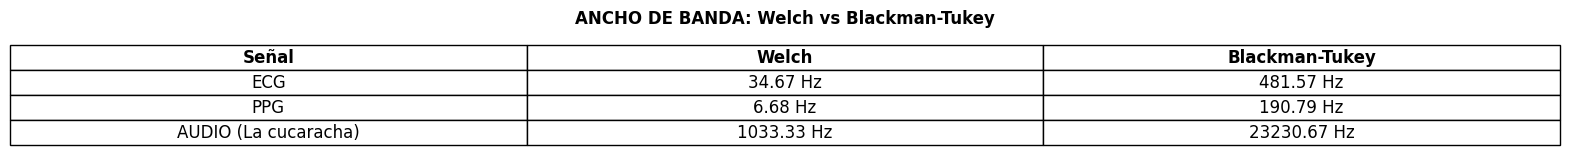

In [10]:
#%% Comparacion de anchos de banda
data = [
    ["ECG", f"{BW_ecg:.2f} Hz", f"{BW_ecg_bt:.2f} Hz"],
    ["PPG", f"{BW_ppg:.2f} Hz", f"{BW_ppg_bt:.2f} Hz"],
    ["AUDIO (La cucaracha)", f"{BW_audio:.2f} Hz", f"{BW_audio_bt:.2f} Hz"],
]

fig, ax = plt.subplots(figsize = (20, 1.5))
ax.axis('off')

tabla = ax.table(cellText = data, colLabels = ["Señal", "Welch", "Blackman-Tukey"], cellLoc = 'center', loc = 'center')

# Esto es para poner en negrita los "titulos"
tabla[0,0].get_text().set_fontweight('bold')
tabla[0,1].get_text().set_fontweight('bold')
tabla[0,2].get_text().set_fontweight('bold')

tabla.scale(1, 1.5)
tabla.auto_set_font_size(False)
tabla.set_fontsize(12)

plt.title("ANCHO DE BANDA: Welch vs Blackman-Tukey", fontweight = 'bold', pad=10)
plt.show()

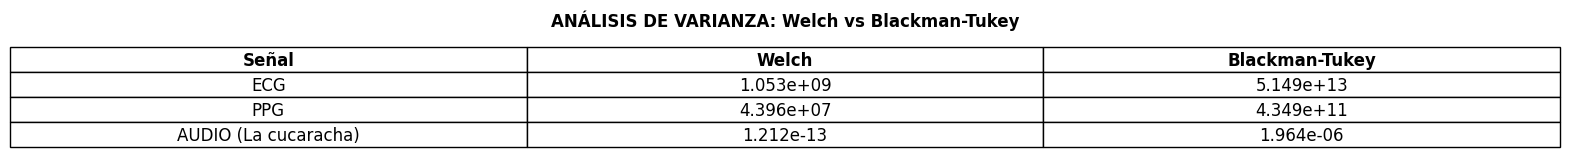

In [12]:
var_ecg_W = (Pxx_ecg ** 2 / cant_promedios_ecg).mean()
var_ppg_W = (Pxx_ppg ** 2 / cant_promedios_ppg).mean()
var_audio_W = (Pxx_audio ** 2 / cant_promedio_audio).mean()

# Energia de la ventana Blackman de cada senal (Ew = sum(w^2))
Ew_ecg   = np.sum(sig.windows.blackman(2 * (N_ECG // 20) - 1) ** 2)
Ew_ppg   = np.sum(sig.windows.blackman(2 * (N_PPG // 20) - 1) ** 2)
Ew_audio = np.sum(sig.windows.blackman(2 * (N_audio // 100) - 1) ** 2)

# Varianza Blackman-Tukey:  Var[P(f)] ~ P(f)^2 * Ew / N
var_ecg_BT = (Px_ecg_bt ** 2 * Ew_ecg / N_ECG).mean()
var_ppg_BT = (Px_ppg_bt ** 2 * Ew_ppg / N_PPG).mean()
var_audio_BT = (Px_audio_bt ** 2 * Ew_audio / N_audio).mean()

#%% Tabla de varianza
data = [
    ["ECG", f"{var_ecg_W:.3e}", f"{var_ecg_BT:.3e}"],
    ["PPG", f"{var_ppg_W:.3e}", f"{var_ppg_BT:.3e}"],
    ["AUDIO (La cucaracha)", f"{var_audio_W:.3e}", f"{var_audio_BT:.3e}"],
]

fig, ax = plt.subplots(figsize = (20, 1.5))
ax.axis('off')

tabla = ax.table(cellText = data, colLabels = ["Señal", "Welch", "Blackman-Tukey"], cellLoc = 'center', loc = 'center')

# Esto es para poner en negrita los "titulos"
tabla[0,0].get_text().set_fontweight('bold')
tabla[0,1].get_text().set_fontweight('bold')
tabla[0,2].get_text().set_fontweight('bold')

tabla.scale(1, 1.5)
tabla.auto_set_font_size(False)
tabla.set_fontsize(12)

plt.title("ANÁLISIS DE VARIANZA: Welch vs Blackman-Tukey", fontweight = 'bold', pad=10)
plt.show()